In [14]:
# using Pkg
# Pkg.add(path="https://github.com/fernandopenaranda/Optics_in_the_length_gauge")
using Optics_in_the_length_gauge
using BZpaths
using Bravais
using LinearAlgebra
using Brillouin
using CairoMakie, LaTeXStrings
using Field_Induced_Hall_Effect


In [10]:
# using Revise # dev
# using Field_Induced_Hall_Effect

## Init - BZ - Constants

In [11]:


a0 = 1#Å
c0 = 1
Rs = (a0 .* [1.0, 0, 0], a0 .* [-1/2, √3/2, 0], [0, 0.0, c0])  # Lattice vectors, can be 2d or 3d
high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A]    # Custom k-path over high symmetry momenta
sgnum = 144                                         # point group (144 = p3_1)
N = 200    

200

In [318]:
kp = irrfbz_path(sgnum, Rs)

KPath{3} (7 points, 3 paths, 13 points in paths):
 points: :M => [0.5, 0.0, 0.0]
         :A => [0.0, 0.0, 0.5]
         :H => [0.333333, 0.333333, 0.5]
         :K => [0.333333, 0.333333, 0.0]
         :Γ => [0.0, 0.0, 0.0]
         :L => [0.5, 0.0, 0.5]
         :H₂ => [0.333333, 0.333333, -0.5]
  paths: [:Γ, :M, :K, :Γ, :A, :L, :H, :A]
         [:L, :M]
         [:H, :K, :H₂]
  basis: [6.283185, 3.627599, -0.0]
         [0.0, 7.255197, 0.0]
         [0.0, -0.0, 6.283185]

In [337]:
Gs = dualbasis(Rs);
cell = wignerseitz(Gs) 

Cell{3} (8 faces, 12 vertices):
  verts: [0.666667, -0.333333, 0.5]
         [0.333333, 0.333333, 0.5]
         [0.333333, 0.333333, -0.5]
         [-0.333333, 0.666667, 0.5]
         [0.333333, -0.666667, 0.5]
         [0.666667, -0.333333, -0.5]
         [-0.333333, -0.333333, 0.5]
         [-0.666667, 0.333333, 0.5]
         [0.333333, -0.666667, -0.5]
         [-0.333333, -0.333333, -0.5]
         [-0.333333, 0.666667, -0.5]
         [-0.666667, 0.333333, -0.5]
  faces: [7, 8, 12, 10]
         [3, 2, 1, 6]
         [5, 9, 6, 1]
         [5, 7, 10, 9]
         [9, 10, 12, 11, 3, 6]
         [5, 1, 2, 4, 8, 7]
         [4, 11, 12, 8]
         [2, 3, 11, 4]
  basis: [6.283185, 3.627599, -0.0]
         [0.0, 7.255197, 0.0]
         [0.0, -0.0, 6.283185]

In [346]:
M = reduce(hcat, cell.verts)  
maxx = findmax(M[1,:][1])
maxy = findmin(M[1,:][1])

(0.6666666666666666, 1)

In [319]:
kpath(Rs, sgnum, N, high_sym_line);

## Bands

In [24]:
function bands(i,q,μ,t1,t2,t3)
    # mat = hamiltonian_TaRh2B2(a,c,t1,t2,t3,q)
    mat = hamiltonian_TaRh2B2(μ,t1,t2,t3,q)
    ϵs, ψs = eigen(mat)   
    return ϵs[i]
end

bs(μ, ts) = bs(μ, ts[1],ts[2],ts[3])
function bs(μ, t1,t2,t3; a = 1, c = 1)
    Rs = (a .* [1.0, 0, 0], a .* [-1/2, √3/2, 0], [0, 0.0, c])  # Lattice vectors
    sgnum = 144                                         # point group (144 = p3_1)
    N = 200    #kpoints
    fig = Figure(); ax = Axis(fig[1,1], ylabel = "E [eV]", title = "t1 = $(t1) eV, t2 = $(t2) eV, t3 = $(t3) eV")
    for i in 1:3
        dispersion(q) = bands(i,q,μ, t1,t2,t3)
        BZpaths.plot_observable_in_kpath!(ax, dispersion, Rs, sgnum, N)#, high_sym_line high_sym_line = [:Γ, :M, :K, :Γ, :A, :L, :H, :A] )
    end
    fig
end

bs (generic function with 2 methods)

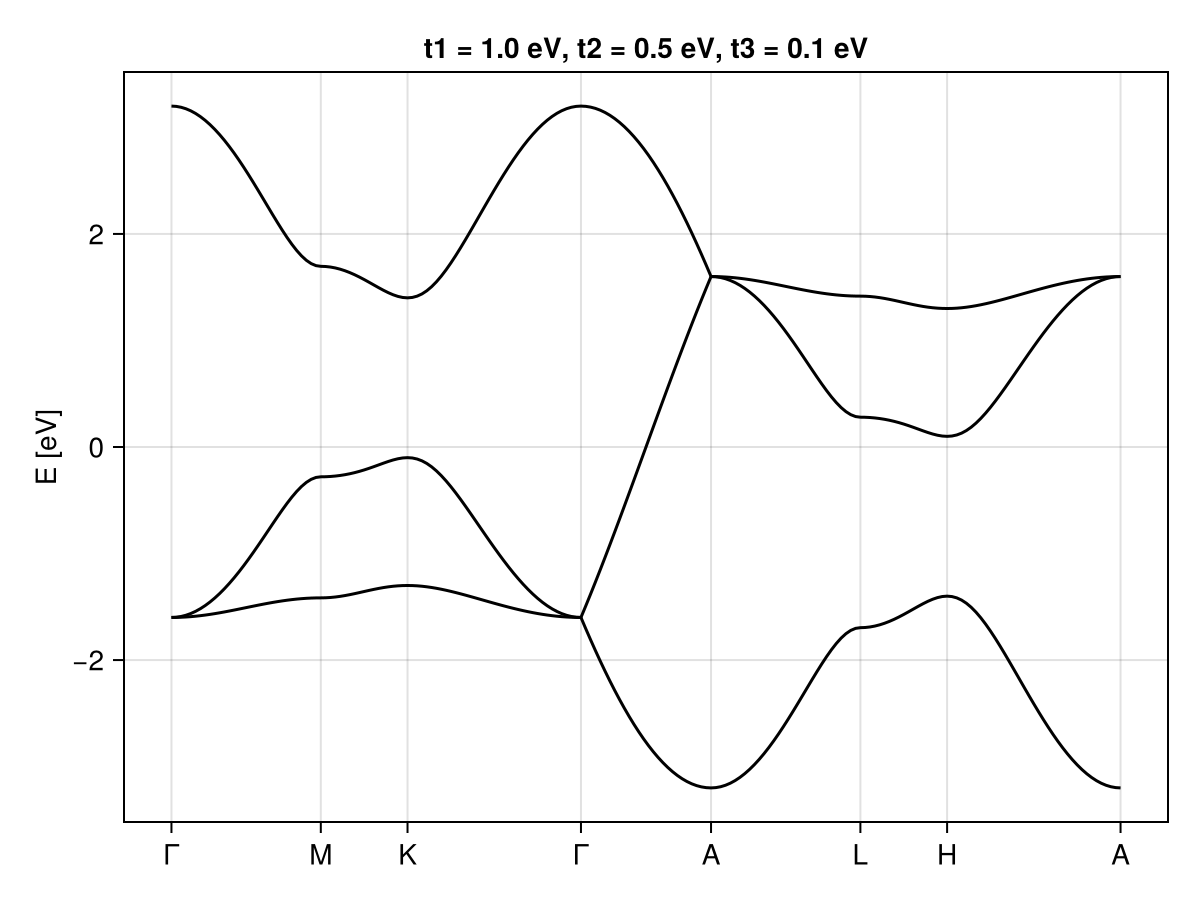

In [25]:
ts = [1,0.5,0.1]
μ = 0
bs(0, ts)